In [2]:
import pandas as pd

train_df = pd.read_csv("../data/raw/train.csv")
train_df.head()
train_df.shape
train_df.info()

target_column = "SalePrice"
feature_columns = [col for col in train_df.columns if col != target_column]
train_df[target_column].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

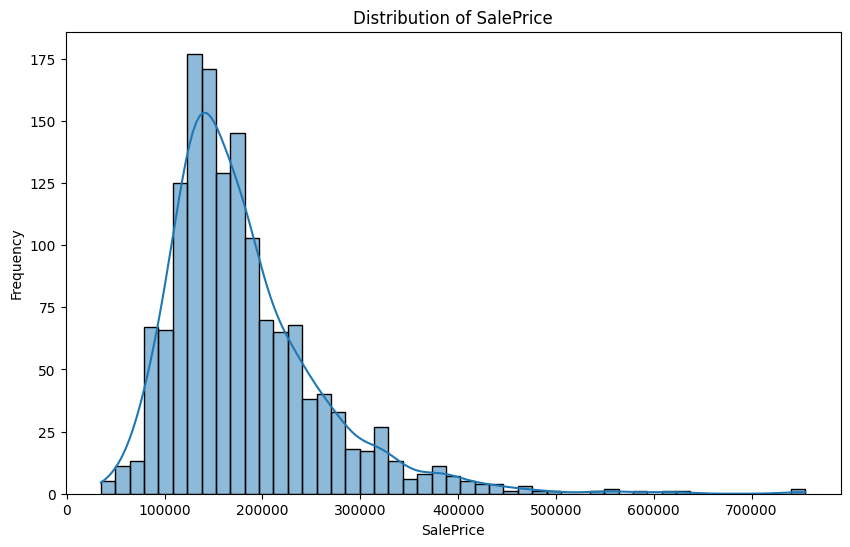

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(train_df[target_column], kde=True)
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()

In [4]:
missing_summary = train_df.isnull().sum().sort_values(ascending=False)
missing_summary.head(10)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
dtype: int64

In [13]:
from sklearn.model_selection import train_test_split

X = train_df.drop("SalePrice", axis=1)
y = train_df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set shape: {X_train.shape}, {y_train.shape}")

y_train.head()

Training set shape: (1168, 80), (1168,)


254     145000
1066    178000
638      85000
799     175000
380     127000
Name: SalePrice, dtype: int64

In [16]:
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
caregory_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, caregory_cols)
])



In [18]:
from sklearn.linear_model import LinearRegression

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

baseline_model.fit(X_train, y_train)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

baseline_predictions = baseline_model.predict(X_test)
mae = mean_absolute_error(y_test, baseline_predictions)
mse = mean_squared_error(y_test, baseline_predictions)

print(f"Baseline MAE: {mae:.2f}")
print(f"Baseline MSE: {mse:.2f}")

Baseline MAE: 18284.68
Baseline MSE: 868845459.54


In [19]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("modeel", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_preds= rf_model.predict(X_test)

from xgboost import XGBRegressor
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

def evaluate_model(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return {
        "model": model_name,
        "MAE": round(mae, 2),
        "MSE": round(mse, 2),
        "RMSE": round(rmse, 2)
    }

results = []
results.append(evaluate_model(y_test, baseline_predictions, "Linear Regression"))
results.append(evaluate_model(y_test, rf_preds, "Random Forest"))
results.append(evaluate_model(y_test, xgb_preds, "XGBoost"))

results_df = pd.DataFrame(results)
results_df 

,model,MAE,MSE,RMSE
0,Linear Regression,18284.68,8.688455e+08,29476.18
1,Random Forest,17467.57,8.164077e+08,28572.85
2,XGBoost,15336.25,5.975850e+08,24445.55


In [21]:
def add_features(df):
    df = df.copy()
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
    df["TotalBath"] = (
        df["FullBath"]
        + 0.5 * df["HalfBath"].fillna(0)
        + df["BsmtFullBath"].fillna(0)
        + 0.5 * df["BsmtHalfBath"].fillna(0)
    )
    df["TotalSF"] = df["TotalBsmtSF"].fillna(0) + df["1stFlrSF"].fillna(0) + df["2ndFlrSF"].fillna(0)
    return df

X_train_fe = add_features(X_train)
X_test_fe = add_features(X_test)


In [24]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    xgb_model,
    X_train_fe,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)

rsme_scores = -cv_scores
print(f"Fold RMSE scores: {rsme_scores}")
print(f"Average RMSE: {rsme_scores.mean():.2f}")

Fold RMSE scores: [14942.84179688 16719.90429688 16867.45703125 16069.49902344
 13020.99804688]
Average RMSE: 15524.14


In [35]:
import os
import joblib

final_model = xgb_model
final_model.fit(X, y)
os.makedirs("models", exist_ok=True)
joblib.dump(final_model, "models/house_price_pipeline.pkl")


['models/house_price_pipeline.pkl']